In [2]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Initial Overview

In [3]:
df = pd.read_csv('../data/synthetic_dataset.csv', converters={'marker': ast.literal_eval})

In [4]:
print("Dataset Shape:", df.shape)
print("-" * 40)
df.info()

Dataset Shape: (1007, 2)
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1007 non-null   str   
 1   marker  1007 non-null   object
dtypes: object(1), str(1)
memory usage: 15.9+ KB


In [5]:
df.head()

,text,marker
0,Just reached the summit of Mt. Rainier!,"[[27, 38]]"
1,The Andes Mountains extend across South America.,"[[4, 19]]"
2,"When hiking through the Carpathian Mountains, ...","[[24, 44]]"
3,Mt Fuji was clearly visible from the train win...,"[[0, 7]]"
4,We camped near the foothills of the Himalayas ...,"[[32, 45]]"


In [6]:
df['mountain_count'] = df['marker'].apply(len)

df['contains_mountain'] = df['mountain_count'] > 0

print(df['contains_mountain'].value_counts())
print("-" * 40)
print(df['contains_mountain'].value_counts(normalize=True) * 100)

contains_mountain
True     1006
False       1
Name: count, dtype: int64
----------------------------------------
contains_mountain
True     99.900695
False     0.099305
Name: proportion, dtype: float64


## Sequence Length Analysis

In [7]:
# Calculate character length and approximate word length
df['char_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

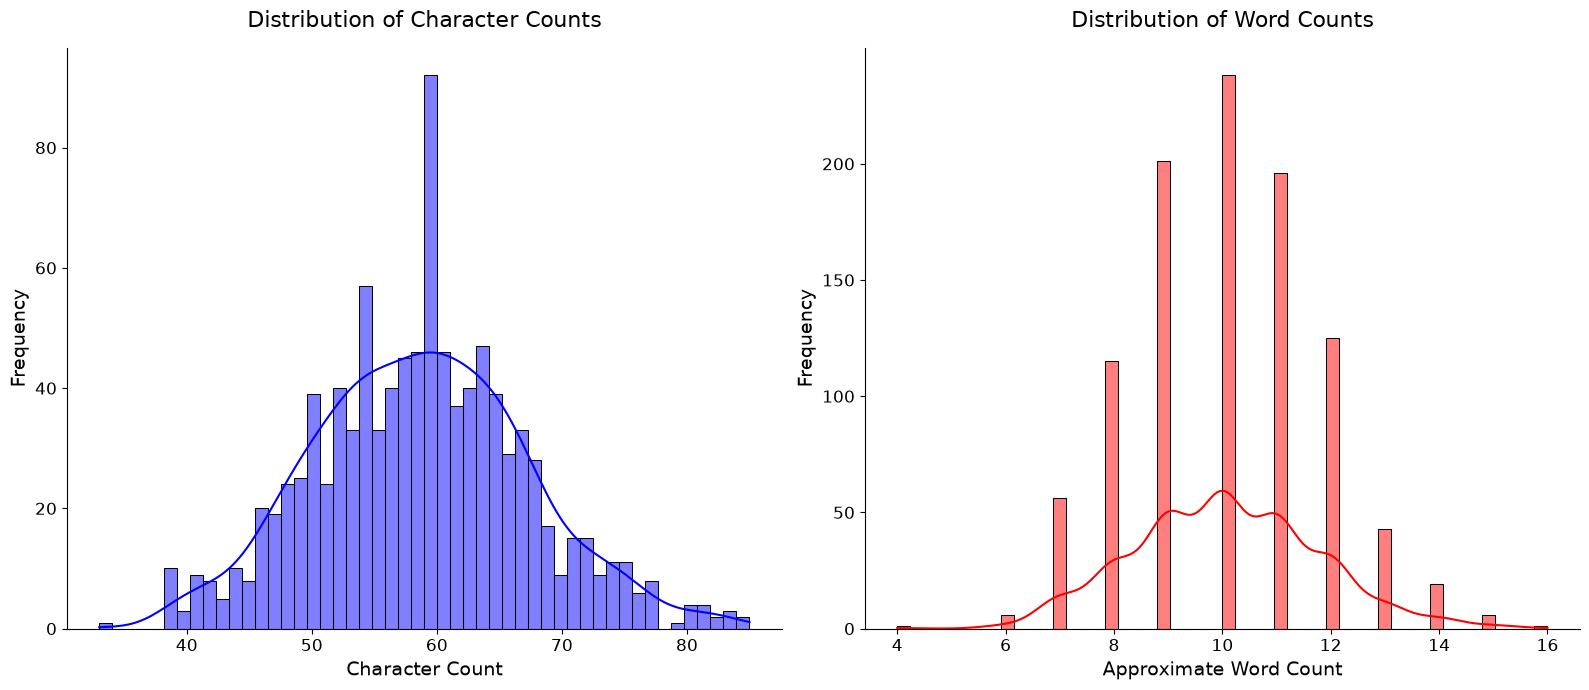

Max word count in a single sentence: 16
NER models like DistilBERT have strict maximum token limits (usually 512).


In [8]:
plt.figure(figsize=(16, 7))

# Plot Character Count
plt.subplot(1, 2, 1)
sns.histplot(df['char_length'], bins=50, kde=True, color='blue', edgecolor='black')
plt.title("Distribution of Character Counts", fontsize=16, pad=15)
plt.xlabel("Character Count", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

# Plot Word Count
plt.subplot(1, 2, 2)
sns.histplot(df['word_count'], bins=50, kde=True, color='red', edgecolor='black')
plt.title("Distribution of Word Counts", fontsize=16, pad=15)
plt.xlabel("Approximate Word Count", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine()

plt.tight_layout()
plt.show()

print(f"Max word count in a single sentence: {df['word_count'].max()}")
print("NER models like DistilBERT have strict maximum token limits (usually 512).")

## Entity Extraction & Frequency Analysis

In [9]:
def extract_full_entities(row):
    """
    Extracts the exact substring from the text using the character indices.
    """
    text = row['text']
    markers = row['marker']
    
    entities = []
    for start, end in markers:
        entities.append(text[start:end])
        
    return entities

In [10]:
df['extracted_mountains'] = df.apply(extract_full_entities, axis=1)

all_mountains = [mountain for sublist in df['extracted_mountains'].tolist() for mountain in sublist]

# Calculate frequencies
mountain_freq = pd.Series(all_mountains).value_counts()

print(f"Total unique mountains: {len(mountain_freq)}")
print("-" * 40)
print("Top 15 Most Frequent Mountains:")
print(mountain_freq.head(15))

Total unique mountains: 246
----------------------------------------
Top 15 Most Frequent Mountains:
Alps                     24
Ben Nevis                22
Himalayas                22
Andes Mountains          21
Sierra Nevada            21
Appalachian Mountains    20
Mount Hood               19
Mt. Rainier              18
Mount Kilimanjaro        18
Atlas Mountains          18
Pyrenees                 18
Table Mountain           18
Carpathian Mountains     17
hill                     17
Ural Mountains           17
Name: count, dtype: int64


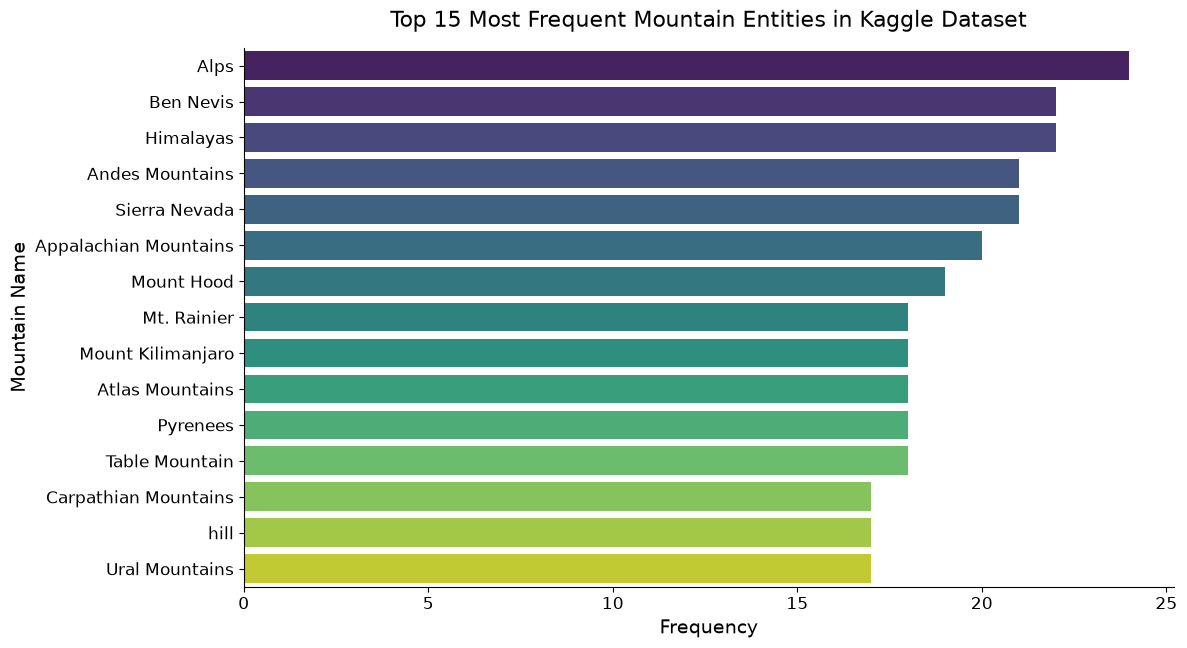

In [11]:
# Visualize the Top 15
plt.figure(figsize=(12, 7))

sns.barplot(
    x=mountain_freq.head(15).values, 
    y=mountain_freq.head(15).index, 
    hue=mountain_freq.head(15).index,
    palette='viridis',
    legend=False
)

plt.title("Top 15 Most Frequent Mountain Entities in Kaggle Dataset", fontsize=16, pad=15)
plt.xlabel("Frequency", fontsize=14)
plt.ylabel("Mountain Name", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove borders
sns.despine()

plt.show()